# CNN+LSTM Model - Dataset m03
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_m03.csv

**Architecture:** CNN layers + Bidirectional LSTM + Dense layers

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, Conv1D, MaxPooling1D, LSTM, 
                                   Dropout, BatchNormalization, Flatten, 
                                   GlobalMaxPooling1D, Bidirectional)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

/Users/giangmytien/Desktop/KLTN/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Load and explore dataset m03
dataset_path = '../dataset step 3/data_features_m03.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (10000, 41)

Columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', 'label']

Label distribution:
label
angry      2000
disgust    2000
fear       2000
neutral    2000
sad        2000
Name: count, dtype: int64

First few rows:


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,label
0,-363.390137,44.644287,-23.034124,-17.677427,5.851917,-12.578137,-21.331135,-5.707288,-9.720257,2.765593,...,2.466654,-4.271550,9.343647,4.869413,-0.862127,-6.002382,1.082896,5.831408,4.037550,angry
1,-193.788753,18.398392,-7.991555,-8.516591,1.003096,-3.129006,-8.301084,-5.554858,-2.004404,1.241974,...,-3.721096,-2.138739,3.497009,3.463667,-1.903568,-2.767768,0.720642,3.116095,-0.121650,angry
2,-352.040344,48.318314,-23.129290,-18.615709,5.261726,-13.030700,-21.941545,-5.982480,-9.404670,3.104637,...,2.590266,-4.528736,8.797647,5.091899,-0.272449,-5.903066,0.680946,5.656840,3.879927,angry
3,-369.379120,49.262260,-31.832554,-22.186298,7.883324,-19.198067,-23.902231,-7.502296,-9.075499,5.022707,...,-0.574394,4.133066,10.288995,-6.241488,-4.152146,-0.267548,9.930678,0.700642,-3.156821,angry
4,-327.850044,55.831194,-36.253744,-32.357412,6.787348,-9.204627,-24.580654,-6.610174,-10.125804,5.195179,...,3.490518,-2.647407,14.996442,8.916438,-1.200445,-5.755606,3.920480,7.840158,4.421846,angry


In [3]:
# Data preprocessing
# Filter for 5 classes only
target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

print(f"Filtered dataset shape: {data_filtered.shape}")
print(f"\nClass distribution after filtering:")
label_counts = data_filtered['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(data_filtered)) * 100
    print(f"   {label}: {count} samples ({percentage:.1f}%)")

# Prepare features and labels
X = data_filtered.drop('label', axis=1).values
y = data_filtered['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Filtered dataset shape: (10000, 41)

Class distribution after filtering:
   angry: 2000 samples (20.0%)
   disgust: 2000 samples (20.0%)
   fear: 2000 samples (20.0%)
   neutral: 2000 samples (20.0%)
   sad: 2000 samples (20.0%)

Features shape: (10000, 40)
Number of features: 40
Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN+LSTM input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 8000
Test samples: 2000
Reshaped train data: (8000, 40, 1)
Reshaped test data: (2000, 40, 1)
Categorical labels shape: (8000, 5)


In [5]:
# Create CNN+LSTM model
def create_cnn_lstm_model(input_shape, num_classes=5):
    """
    Create CNN+LSTM model for speech emotion recognition
    
    Architecture:
    1. Convolutional layers for local feature extraction
    2. LSTM layers for temporal modeling
    3. Dense layers for classification
    """
    
    inputs = Input(shape=input_shape, name='input')
    
    # CNN Block 1
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv1d_1')(inputs)
    x = BatchNormalization(name='bn_1')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_1')(x)
    x = Dropout(0.25, name='dropout_1')(x)
    
    # CNN Block 2
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same', name='conv1d_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_2')(x)
    x = Dropout(0.25, name='dropout_2')(x)
    
    # CNN Block 3
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same', name='conv1d_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(0.25, name='dropout_3')(x)
    
    # LSTM Blocks
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3), name='bilstm_1')(x)
    x = Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3), name='bilstm_2')(x)
    
    # Dense layers
    x = Dense(256, activation='relu', name='dense_1')(x)
    x = BatchNormalization(name='bn_final')(x)
    x = Dropout(0.5, name='dropout_final')(x)
    
    x = Dense(128, activation='relu', name='dense_2')(x)
    x = Dropout(0.3, name='dropout_dense')(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    model = Model(inputs, outputs, name='CNN_LSTM_EmotionRecognition')
    return model

# Build model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_cnn_lstm_model(input_shape)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN+LSTM model created and compiled!")
model.summary()

CNN+LSTM model created and compiled!


Model: "CNN_LSTM_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 20, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 10, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 10, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 10, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_final (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,493 (2.87 MB)

 Trainable params: 750,085 (2.86 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [6]:
# Training
print("Starting training...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

#model_checkpoint = ModelCheckpoint(
#    'best_cnn_lstm_f01.h5',
#    monitor='val_accuracy',
#    save_best_only=True,
#    verbose=1
#)

# Train model
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.6278 - loss: 1.0300 - val_accuracy: 0.3065 - val_loss: 1.9174 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.9521 - loss: 0.1355 - val_accuracy: 0.9725 - val_loss: 0.0879 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.9731 - loss: 0.0827 - val_accuracy: 0.9925 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.9815 - loss: 0.0547 - val_accuracy: 0.9980 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.9854 - loss: 0.0436 - val_accuracy: 0.9970 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.9911 - loss: 0.0293 - val_accuracy: 0.9975 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms

In [7]:
# Evaluation and Results
print("CNN+LSTM MODEL EVALUATION - Dataset m03")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CNN+LSTM MODEL EVALUATION - Dataset m03
Test Accuracy: 1.0000
Test Loss: 0.0009

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     1.0000    1.0000    1.0000       400
     disgust     1.0000    1.0000    1.0000       400
        fear     1.0000    1.0000    1.0000       400
     neutral     1.0000    1.0000    1.0000       400
         sad     1.0000    1.0000    1.0000       400

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000


Cohen's Kappa Score: 1.0000

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.9998
Final Validation Accuracy: 0.9995
Final Training Loss: 0.0009
Final Validation Loss: 0.0016
Epochs Trained: 49



CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   400       0         0         0         0         
disgust 0         400       0         0         0         
fear    0         0         400       0         0         
neutral 0         0         0         400       0         
sad     0         0         0         0         400       


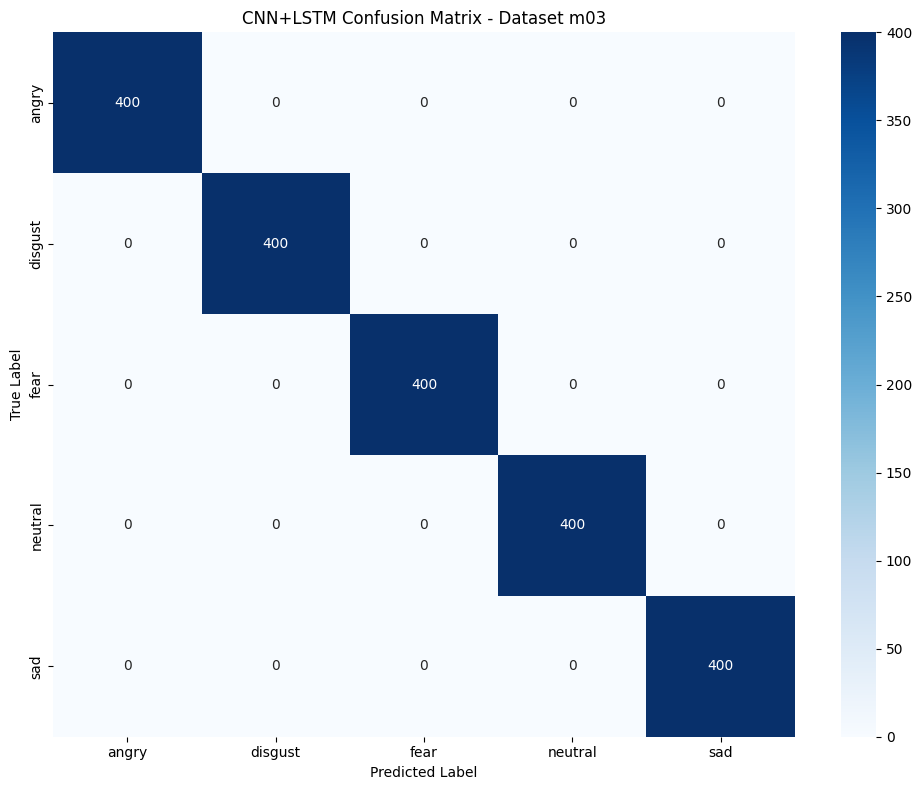

In [8]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('CNN+LSTM Confusion Matrix - Dataset m03')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

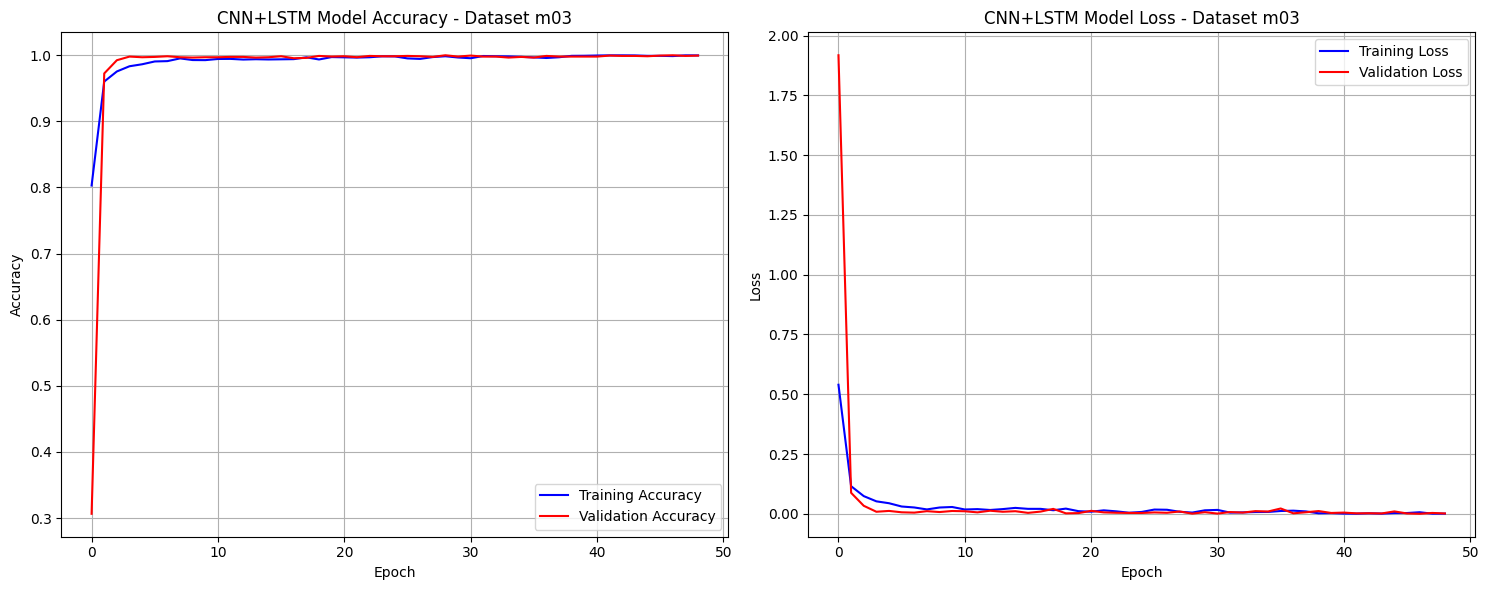

Training history plots generated!


In [9]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('CNN+LSTM Model Accuracy - Dataset m03')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('CNN+LSTM Model Loss - Dataset m03')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [ ]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - CNN+LSTM m03")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_m03.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - CNN+LSTM m03
Test Accuracy: 1.0000
Cohen's Kappa: 1.0000
Epochs Trained: 49
Dataset: data_features_m03.csv
Classes: angry, disgust, fear, neutral, sad


: 